# Chapter 4 — Case Study: Groundwater Level Trends, Hennaya Plain

**AI for Hydrogeologists** — companion notebook

**Note on scope.** The book outline originally planned monthly time-series
forecasting (Random Forest / LSTM) as in Section 4.2-4.3. The Hennaya
piezometric record consists of three independent snapshots (1981, 2012,
2022), not a continuous monthly series, so per-well forecasting is not
applicable. Well field labels (e.g. "P1") are also not physically consistent
across the three campaigns (confirmed with the data owner), so a per-well
"rate of change" cannot be computed by matching IDs either.

This notebook instead performs the methodologically correct alternative for
this data structure: each campaign is interpolated onto a common spatial
grid (Inverse Distance Weighting), restricted to the area sampled in **all
three** campaigns, and the interpolated surfaces are differenced to obtain
spatially distributed rates of change between 1981-2012 and 2012-2022.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree, ConvexHull
from matplotlib.path import Path

BASE = "https://raw.githubusercontent.com/Dr-LAOUFIAbdessalam/ai-hydrogeologists/main/"
heads = pd.read_csv(BASE + "ch04_groundwater_level/data/raw/heads_clean.csv")
print(heads.shape)
heads.head()


(166, 8)


,well_id,field_label,campaign_year,x,y,screen_elev_m,head_m,head_minus_screen
0,HYN-1981-001,P7,1981,646327.9586,3868315.949,375.547597,379.77,4.222403
1,HYN-1981-002,P2,1981,647889.1564,3869861.394,342.829073,348.80,5.970927
2,HYN-1981-003,P3,1981,647580.7659,3869993.347,347.986015,347.60,-0.386015
3,HYN-1981-004,P4,1981,647275.3298,3870075.383,340.580420,349.20,8.619580
4,HYN-1981-005,P37,1981,650822.3555,3870236.068,349.075910,361.10,12.024090


## Drop the physically implausible record flagged in Chapter 2

In [2]:
heads = heads[heads["well_id"] != "HYN-2022-033"].copy()
print("Records per campaign:")
print(heads.groupby("campaign_year").size())


Records per campaign:
campaign_year
1981    30
2012    41
2022    94
dtype: int64


## Interpolate each campaign (IDW) and restrict to the common overlap area

In [3]:
def idw_grid(x, y, z, grid_x, grid_y, power=2, k=8):
    tree = cKDTree(np.column_stack([x, y]))
    gx, gy = np.meshgrid(grid_x, grid_y)
    pts = np.column_stack([gx.ravel(), gy.ravel()])
    dist, idx = tree.query(pts, k=min(k, len(x)))
    dist = np.where(dist == 0, 1e-6, dist)
    w = 1.0 / dist**power
    z_interp = np.sum(w * z[idx], axis=1) / np.sum(w, axis=1)
    return z_interp.reshape(gx.shape), gx, gy

xmin, xmax = heads["x"].min() - 200, heads["x"].max() + 200
ymin, ymax = heads["y"].min() - 200, heads["y"].max() + 200
res = 60
gx1d = np.arange(xmin, xmax, res)
gy1d = np.arange(ymin, ymax, res)

surfaces, hulls = {}, {}
for year in [1981, 2012, 2022]:
    sub = heads[heads["campaign_year"] == year]
    x, y, z = sub["x"].values, sub["y"].values, sub["head_m"].values
    Z, GX, GY = idw_grid(x, y, z, gx1d, gy1d)
    surfaces[year] = Z
    hull = ConvexHull(np.column_stack([x, y]))
    hulls[year] = Path(np.column_stack([x, y])[hull.vertices])

gx, gy = np.meshgrid(gx1d, gy1d)
pts = np.column_stack([gx.ravel(), gy.ravel()])
mask = np.ones(len(pts), dtype=bool)
for year in [1981, 2012, 2022]:
    mask &= hulls[year].contains_points(pts)
mask = mask.reshape(gx.shape)

for year in surfaces:
    surfaces[year] = np.where(mask, surfaces[year], np.nan)

print(f"Grid: {gx.shape}, cells inside the common overlap area: {mask.sum()}")


Grid: (177, 85), cells inside the common overlap area: 5314


## Rate of change between campaigns

In [4]:
diff_81_12 = surfaces[2012] - surfaces[1981]
rate_81_12 = diff_81_12 / (2012 - 1981)

diff_12_22 = surfaces[2022] - surfaces[2012]
rate_12_22 = diff_12_22 / (2022 - 2012)

for name, arr in [("1981->2012 rate (m/yr)", rate_81_12), ("2012->2022 rate (m/yr)", rate_12_22)]:
    print(f"{name}: mean={np.nanmean(arr):.3f}  min={np.nanmin(arr):.3f}  max={np.nanmax(arr):.3f}")

pct_declining_1 = 100 * np.sum(rate_81_12 < 0) / np.sum(~np.isnan(rate_81_12))
pct_declining_2 = 100 * np.sum(rate_12_22 < 0) / np.sum(~np.isnan(rate_12_22))
print(f"\n% of overlap area with declining head, 1981-2012: {pct_declining_1:.1f}%")
print(f"% of overlap area with declining head, 2012-2022: {pct_declining_2:.1f}%")


1981->2012 rate (m/yr): mean=0.187  min=-0.373  max=0.893
2012->2022 rate (m/yr): mean=0.112  min=-2.594  max=2.389

% of overlap area with declining head, 1981-2012: 15.8%
% of overlap area with declining head, 2012-2022: 29.0%


**Key finding:** the mean rate is positive in both periods (heads rising
overall), yet the fraction of the study area experiencing local decline
nearly doubles between the two periods (roughly 16% to 29%). The aquifer
response is spatially heterogeneous rather than uniformly depleting or
recovering — see the precipitation context below for a plausible driver.

## Figure: heads, rates of change, and acceleration

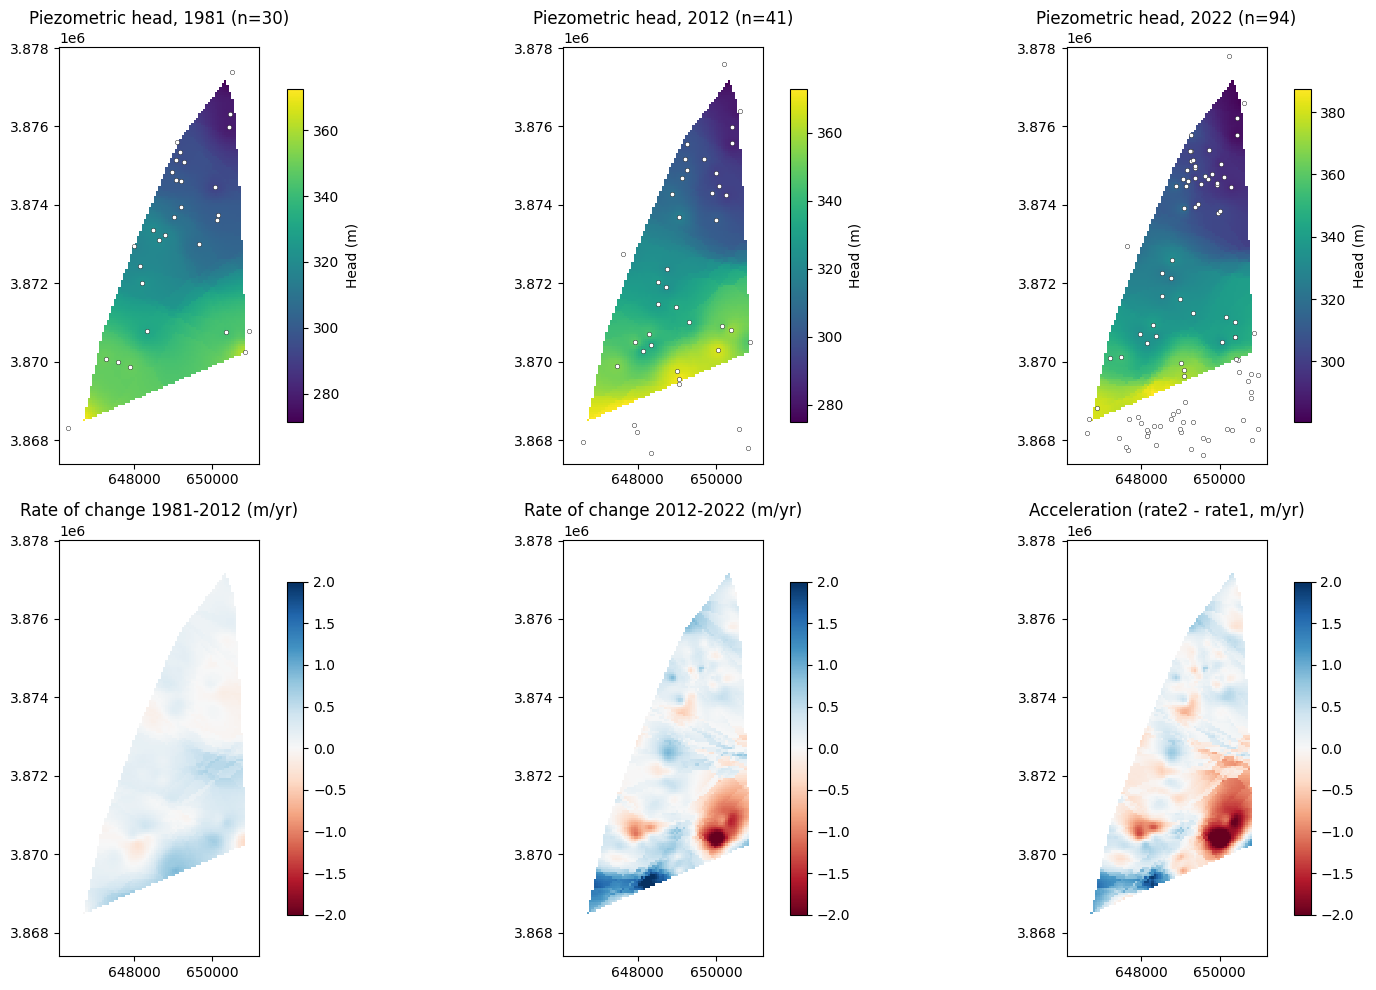

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, year in zip(axes[0], [1981, 2012, 2022]):
    sub = heads[heads["campaign_year"] == year]
    im = ax.pcolormesh(gx, gy, surfaces[year], cmap="viridis", shading="auto")
    ax.scatter(sub["x"], sub["y"], c="white", s=10, edgecolor="k", linewidth=0.3)
    ax.set_title(f"Piezometric head, {year} (n={len(sub)})")
    ax.set_aspect("equal")
    plt.colorbar(im, ax=ax, label="Head (m)", shrink=0.8)

im1 = axes[1][0].pcolormesh(gx, gy, rate_81_12, cmap="RdBu", vmin=-2, vmax=2, shading="auto")
axes[1][0].set_title("Rate of change 1981-2012 (m/yr)")
plt.colorbar(im1, ax=axes[1][0], shrink=0.8)

im2 = axes[1][1].pcolormesh(gx, gy, rate_12_22, cmap="RdBu", vmin=-2, vmax=2, shading="auto")
axes[1][1].set_title("Rate of change 2012-2022 (m/yr)")
plt.colorbar(im2, ax=axes[1][1], shrink=0.8)

accel = rate_12_22 - rate_81_12
im3 = axes[1][2].pcolormesh(gx, gy, accel, cmap="RdBu", vmin=-2, vmax=2, shading="auto")
axes[1][2].set_title("Acceleration (rate2 - rate1, m/yr)")
plt.colorbar(im3, ax=axes[1][2], shrink=0.8)

for ax in axes[1]:
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("hennaya_head_trend_maps.png", dpi=150)
plt.show()


## Precipitation context (Zenata station)

In [6]:
precip = pd.read_excel(BASE + "ch02_data_preparation/data/raw/Precipitations_mensuelles.xlsx")
months = ["Sep","Oct","Nov","Dec","Jan","Fev","Mars","Avr","Mai","Juin","Juill","Aout"]
precip["P_annual_mm"] = precip[months].sum(axis=1)
precip["hydro_year_start"] = precip["Année_hydro"].str.split("/").str[0].astype(int)
precip.loc[precip["hydro_year_start"] == 1980, "P_annual_mm"] = np.nan
mean_annual = precip["P_annual_mm"].mean()

def anomaly_before(census_year, n=5):
    window = precip[(precip["hydro_year_start"] >= census_year - n) &
                     (precip["hydro_year_start"] <= census_year - 1)]
    return 100 * (window["P_annual_mm"].mean() - mean_annual) / mean_annual

for y in [2012, 2022]:
    a = anomaly_before(y)
    print(f"{y}: 5-year precipitation anomaly before campaign = {a:+.1f}%")


2012: 5-year precipitation anomaly before campaign = +17.0%
2022: 5-year precipitation anomaly before campaign = -16.0%


**Interpretation:** the 5-year precipitation anomaly before the 2012 census
is positive (wetter than the 45-year mean), consistent with the generally
rising heads observed 1981-2012. The anomaly before the 2022 census is
negative (drier), consistent with the expanding local decline zones despite
the overall mean rate remaining positive — plausibly reflecting aquifer
storage inertia responding with a multi-year lag to recent drought. This
link is suggestive, not proof of causation, given the single climate
station and the coarse three-snapshot temporal resolution.

**Data limitation to note explicitly:** the precipitation record begins in
1980/81, exactly at the first census, so no pre-survey climatic context
exists for the 1981 baseline itself.